In [309]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

### Path specification

In [310]:
dataset = 'keypoint_samples.csv'
model_save_path = 'keypoint_classifier.keras'
tflite_save_path = 'keypoint_classifier.tflite'

### Set number of classes

In [311]:
NUM_CLASSES = 12

### Dataset reading

In [312]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [313]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [314]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

### Model building

In [315]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [316]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_28 (Dropout)            │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 20)             │           860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 12)             │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,202 (4.70 KB)

 Trainable params: 1,202 (4.70 KB)

 Non-trainable params: 0 (0.00 B)

In [317]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=50, verbose=1)

In [318]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Model training

In [319]:
model.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/500


76/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0892 - loss: 2.5087
Epoch 1: saving model to keypoint_classifier.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0914 - loss: 2.5025 - val_accuracy: 0.1810 - val_loss: 2.4029
Epoch 2/500
85/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1279 - loss: 2.4099
Epoch 2: saving model to keypoint_classifier.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1299 - loss: 2.4063 - val_accuracy: 0.2399 - val_loss: 2.2281
Epoch 3/500
82/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1871 - loss: 2.2587
Epoch 3: saving model to keypoint_classifier.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1892 - loss: 2.2533 - val_accuracy: 0.3207 - val_loss: 1.9998
Epoch 4/500
77/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2400 - loss: 2.0824
Epoch 4: saving model to keypoint_classifier.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2415 - loss: 2.0773 - val_accuracy: 0.3724 - val_loss: 1.7928
Epoch 5/

In [320]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8410 - loss: 0.6577


In [321]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [322]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[9.8921661e-04 1.5473462e-02 2.8017137e-04 7.9950364e-04 1.1762023e-02
 7.8887492e-01 5.1020738e-04 4.1359407e-03 3.3057213e-02 1.4286631e-01
 7.9345738e-04 4.5762848e-04]
5


### Confusion matrix

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step


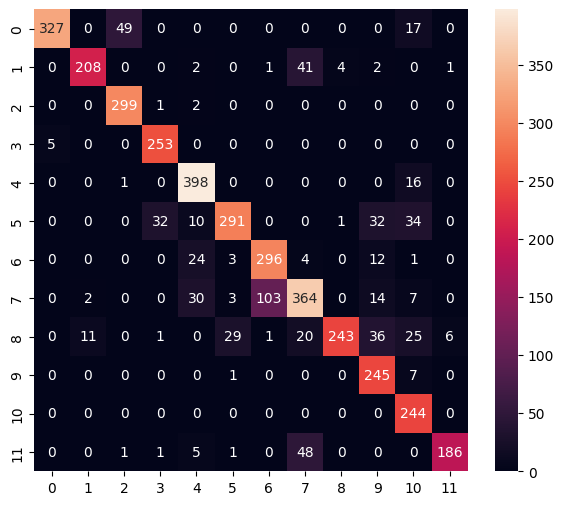

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       393
           1       0.94      0.80      0.87       259
           2       0.85      0.99      0.92       302
           3       0.88      0.98      0.93       258
           4       0.85      0.96      0.90       415
           5       0.89      0.73      0.80       400
           6       0.74      0.87      0.80       340
           7       0.76      0.70      0.73       523
           8       0.98      0.65      0.78       372
           9       0.72      0.97      0.82       253
          10       0.70      1.00      0.82       244
          11       0.96      0.77      0.86       242

    accuracy                           0.84      4001
   macro avg       0.85      0.85      0.84      4001
weighted avg       0.85      0.84      0.84      4001



In [323]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

### Convert to model for Tensorflow-Lite

In [324]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [325]:
# Convert model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\renat\AppData\Local\Temp\tmpox906s1v\assets


INFO:tensorflow:Assets written to: C:\Users\renat\AppData\Local\Temp\tmpox906s1v\assets


Saved artifact at 'C:\Users\renat\AppData\Local\Temp\tmpox906s1v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_14')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  2770482394320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2770482394896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2770482396432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2770482396624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2770482382608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2770004728656: TensorSpec(shape=(), dtype=tf.resource, name=None)


6924

### Inference test

In [326]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [327]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [328]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [329]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [330]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[9.8921743e-04 1.5473454e-02 2.8017149e-04 7.9950440e-04 1.1762016e-02
 7.8887492e-01 5.1020738e-04 4.1359388e-03 3.3057213e-02 1.4286631e-01
 7.9345808e-04 4.5762828e-04]
5
